# 第6章 大样本OLS

## 6.1 为何需要大样本理论

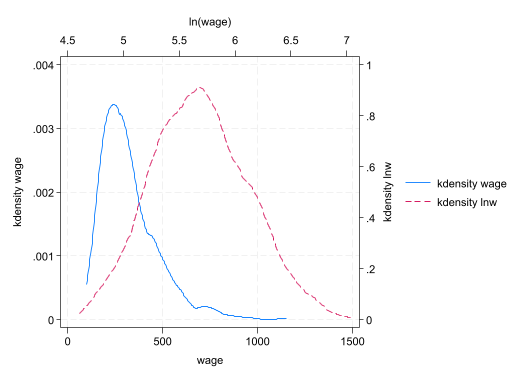

In [1]:
* 下面将数据集grilic.dta的工资与工资对数的核密度图画在一起
use data/grilic.dta,clear
gen wage=exp(lnw)
* 选择项“xaxis(1)yaxis(1)”与“xaxis(2)yaxis(2)”指定对于变量wage与lnw分别使用不同的x轴与y轴，因为这两个变量的取值范围与概率密度均很不相同；
* 选择项“xvarlab(wage)”与“xvarlab(ln(wage))”将变量wage与lnw核密度图的横轴标签分别指定为“wage”与“ln(wage)”
twoway kdensity wage,xaxis(1) yaxis(1) xvarlab(wage) || kdensity lnw,xaxis(2) yaxis(2) xvarlab(ln(wage)) lp(dash)

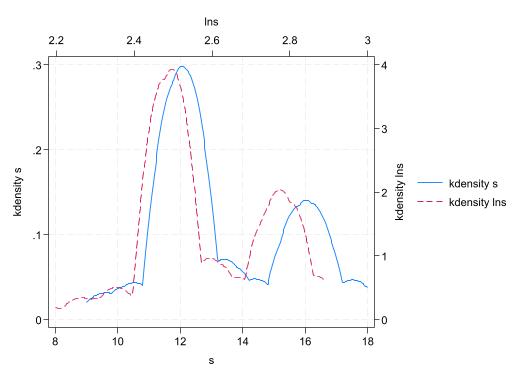

In [2]:
* 将教育年限(s)与其对数(lns)的核密度图画在一起
gen lns=log(s)
twoway kdensity s,xaxis(1) yaxis(1) xvarlab(s) || kdensity lns,xaxis(2) yaxis(2) xvarlab(lns) lp(dash)

教育年限的分布呈现“双峰”形状，即多数人为中学或大学毕业。这种双峰形状，即使取对数后，也难以改变。因此，无论是教育年限还是其对数的分布，都与“单峰”的正态分布相去甚远。

## 6.2 随机收敛

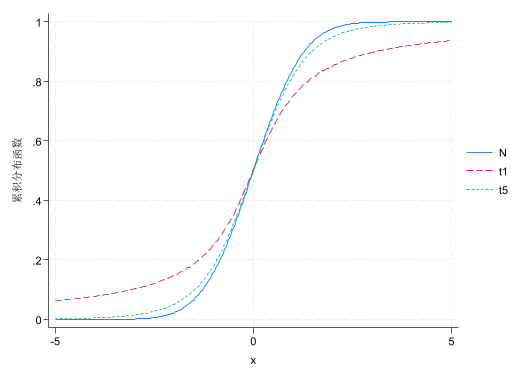

In [3]:
* 为了直观地显示依分布收敛的过程，下面在Stata中画N(0,1)，t(1)与t(5)的累积分布函数
* 选择项“1p(shortdash)”表示以短横来画线。
twoway function N=normal(x) ,range(-5 5) || function t1=t(1,x),range(-5 5)  lp(dash) || function t5=t(5,x),range(-5 5)  lp(shortdash) ytitle("累积分布函数")

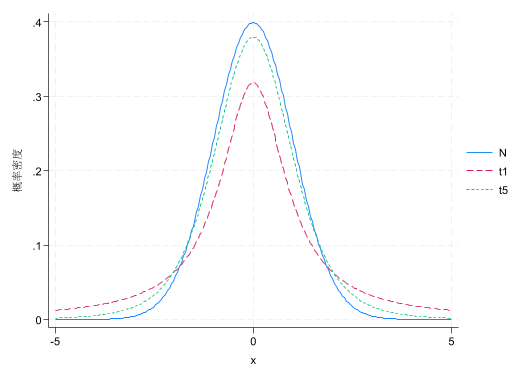

In [4]:
* 更直观地，可以通过概率密度函数来考察t分布依分布收敛于标准正态的过程
twoway function N=normalden(x) ,range(-5 5) || function t1=tden(1,x),range(-5 5) lp(dash) || function t5=tden(5,x),range(-5 5)  lp(shortdash) ytitle("概率密度")

## 6.4 使用蒙特卡罗法模拟中心极限定理

In [5]:
* 定义程序onesample,并以r()形式储存结果
program onesample,rclass
  * 删去内存中已有数据
  drop _all
  * 确定随机抽样的样本容量为30
  set obs 30
  * 得到在(0,1)上均匀分布的随机样本
  gen x=runiform()
  * 也可以改成卡方分布的随机样本
  * gen x=rchi2(10)
  * 使用命令sum计算样本均值
  sum x
  * 将样本均值记为mean_sample
  return scalar mean_sample=r(mean)
end
* 指定Stata输出结果连续翻页
set more off
* 选择项“reps(10000)”表示，命令simulate将运行“onesample”程序10000遍，并生成变量xbar来记录这10 000个样本均值
* 选择项“nodots”表示不显示模拟过程的点点
simulate xbar=r(mean_sample),seed(101) reps(10000) nodots: onesample



      Command: onesample
         xbar: r(mean_sample)



(bin=40, start=.30437654, width=.00956531)


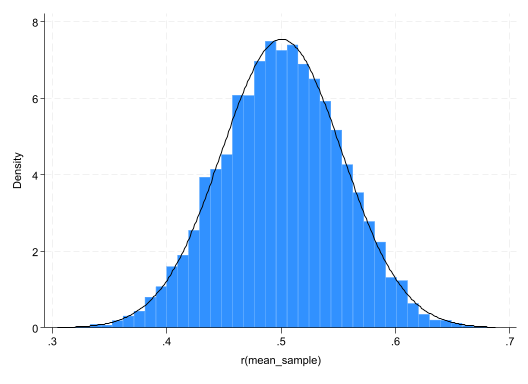

In [6]:
* 选择项“normal”表示画出相应的正态分布
hist xbar,normal

## 6.5 统计量的大样本性质

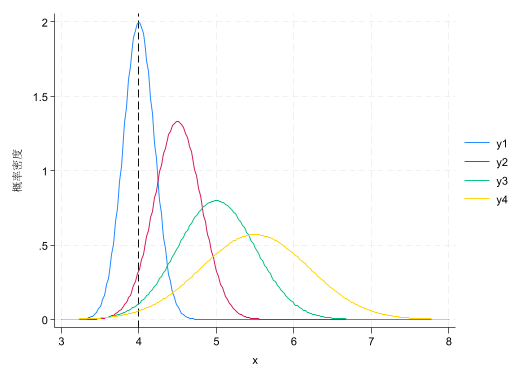

In [7]:
* 一致估计量示意图
twoway function y1=normalden(x,4,.2),range(3 8) || function y2=normalden(x,4.5,.3),range(3 8)  || function y3= normalden(x,5,.5),range(3 8) || function y4=normalden(x,5.5,.7),range(3 8) xline(4) ytitle("概率密度")

## 6.6 随机过程的性质

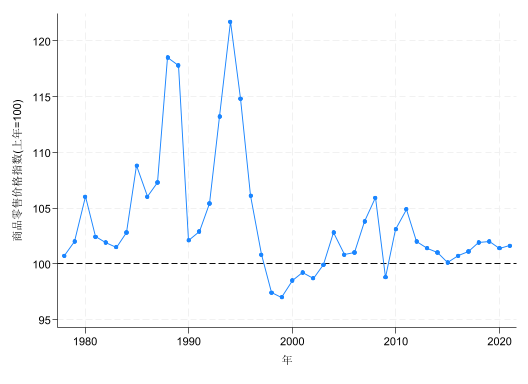

In [8]:
* 数据集price_retail.dta包含中国1978—2021年的通货膨胀率数据(商品零售价格指数，上年=100)
use data/price_retail.dta,clear
* 选择项“yline(100,lp(dash))”指定在纵轴等于100的位置画一条水平的虚线
graph twoway connect price year,yline(100,lp(dash))

## 6.10 大样本OLS的Stata命令及实例

nerlove.dta数据集包括1955年美国145家电力企业的横截面数据，主要变量为 $TC$(total cost，总成本)，$Q$(total output，总产量)，$P_L$(price of labor，小时工资率)，$P_K$(user cost of capital，资本的使用成本)与$P_F$(price of fuel，燃料价格)，以及相应的对数值。

取对数后得到如下模型：
$$
\ln TC_i=\beta_1+\frac{1}{r}\ln Q_i+\frac{\alpha_1}{r}\ln P_{L,i}+\frac{\alpha_2}{r}\ln P_{K,i}+\frac{\alpha_3}{r}\ln P_{F,i}+\epsilon_i
$$

In [9]:
use data/nerlove.dta,clear
* 使用普通标准误对上面方程进行OLS估计
reg lntc lnq lnpl lnpk lnpf

(Nerlove 1963 paper)

      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(4, 140)       =    437.90
       Model |  269.524728         4  67.3811819   Prob > F        =    0.0000
    Residual |  21.5420958       140  .153872113   R-squared       =    0.9260
-------------+----------------------------------   Adj R-squared   =    0.9239
       Total |  291.066823       144  2.02129738   Root MSE        =    .39227

------------------------------------------------------------------------------
        lntc | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .7209135   .0174337    41.35   0.000     .6864462    .7553808
        lnpl |   .4559645    .299802     1.52   0.131    -.1367602    1.048689
        lnpk |  -.2151476   .3398295    -0.63   0.528    -.8870089    .4567136
        lnpf |   .4258137   .

* $R^2$=0.9260，$\bar{R}^2$=0.9239，检验整个方程显著性的F统计量高达
437.9，其相应p值(Prob>F)为0.0000，表明此回归方程高度显著。
* lnpl与lnpk这两个变量均不显著，其p值(P>|t|)分别为0.131与0.528。
* 变量lnpk的系数(Coef.)符号为负，与经济理论的预测相反。Nerlove(1963)认为，这是由于“资本使用成本”的数据不太可靠。

In [10]:
* 由于lnq的系数为1/r(即规模报酬的倒数)，故可估计规模报酬为：
* “_b[1nq]”表示lnq的OLS系数估计值
display 1/_b[lnq]

1.387129


由于$\hat r$=1.387129>1，故认为可能存在规模报酬递增。为此，检验规模报酬不变的原假设$H_0:r=1$，可输入命令

In [11]:
test lnq=1


 ( 1)  lnq = 1

       F(  1,   140) =  256.27
            Prob > F =    0.0000


由于p值为0.0000，故可强烈拒绝原假设，认为存在规模报酬递增。

In [12]:
* 其次，使用稳健标准误重新进行回归：
reg lntc lnq lnpl lnpk lnpf,r


Linear regression                               Number of obs     =        145
                                                F(4, 140)         =     177.19
                                                Prob > F          =     0.0000
                                                R-squared         =     0.9260
                                                Root MSE          =     .39227

------------------------------------------------------------------------------
             |               Robust
        lntc | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .7209135   .0325376    22.16   0.000      .656585     .785242
        lnpl |   .4559645    .260326     1.75   0.082    -.0587139    .9706429
        lnpk |  -.2151476   .3233711    -0.67   0.507    -.8544698    .4241745
        lnpf |   .4258137   .0740741     5.75   0.000     .2793653    .5722622
       _cons |

* 对比以上两个回归的结果可知，使用选择项“robust”所得到的OLS回归系数与不使用选择项“robust”所得到的OLS回归系数完全相同，只是所得到的稳健标准误(Robust std.Err.)与普通标准误(Sta.Err.)不同。
* 对于变量lnq的系数，其稳健标准误(0.033)几乎是普通标准误(0.017)的两倍。另一方面，其他变量系数的稳健标准误反而比普通标准误有所下降。
* 如果认为存在异方差，则应使用稳健标准误。在存在异方差的情况下，如果使用普通标准误，将大大低估变量lnq系数的真实标准误，从而导致不正确的统计推断。

In [13]:
* 检验变量lnq的系数是否为1:
test lnq=1


 ( 1)  lnq = 1

       F(  1,   140) =   73.57
            Prob > F =    0.0000


由于p值为0.0000,故即使使用稳健标准误，也仍然强烈拒绝“变量lnq的系数为1”的原假设。

## 6.11 大样本理论的蒙特卡罗模拟

考虑以下数据生成过程（DGP）：

$$
y=\alpha+\beta x+\epsilon, x \sim \chi^2(1), \epsilon \sim \chi^2(10)-10
$$

其中，$\alpha$=1，$\beta$=2，解释变量$x$服从$\chi^2(1)$分布；而扰动项$\epsilon$服从经过位移后的$\chi^2(10)$分布，以保证其期望为零(卡方分布的期望为其自由度)；而且$x$与$\epsilon$相互独立。

In [14]:
program chi2data_20,rclass
  drop _all
  set obs 20
  gen x = rchi2(1)
  gen y = 1 + 2*x + rchi2(10)-10
  reg y x
  return scalar b=_b[x]
end
set more off
simulate bhat=r(b),reps(10000) seed(10101) nodots:chi2data_20



      Command: chi2data_20
         bhat: r(b)



In [15]:
* 计算均值与标准差：
sum bhat


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        bhat |     10,000    2.007048    .9918413  -6.570165   8.955813


从上表可知，$\hat\beta$的样本均值为2.0071，很接近真实值2，验证了$\hat\beta$为$\beta$的无偏估计。但标准(误)差为0.992，接近于1，故估计误差较大(因为样本容量仅为20)。

(bin=40, start=-6.5701647, width=.38814945)


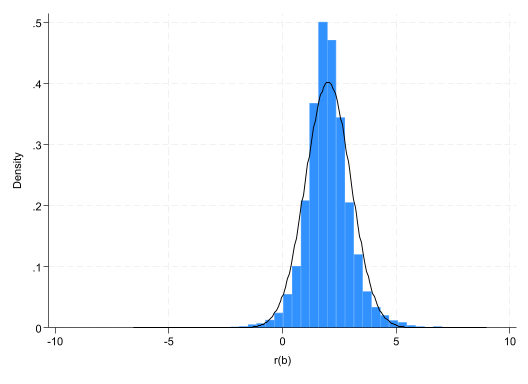

In [16]:
* 选择项“normal”表示同时画相应的正态分布密度图
hist bhat,normal

当样本容量为20时，$\hat\beta$的真实分布与正态分布仍有一定差距。

In [17]:
program chi2data_100,rclass
  drop _all
  set obs 100
  gen x = rchi2(1)
  gen y = 1 + 2*x + rchi2(10)-10
  reg y x
  return scalar b=_b[x]
end
simulate bhat=r(b),reps(10000) seed(10101) nodots:chi2data_100



      Command: chi2data_100
         bhat: r(b)



In [18]:
sum bhat


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        bhat |     10,000     2.00086    .3378564   .7553486   3.522173


从上表可知，$\hat\beta$的样本均值为2.00086，更加接近真实值2。更重要的是，当样本容量从20增加到100后，$\hat\beta$的标准(误)差从0.992下降到0.338。

(bin=40, start=.75534856, width=.06917062)


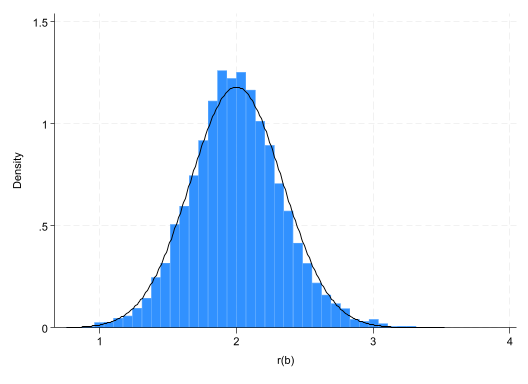

In [19]:
hist bhat,normal

样本容量为100时，$\hat\beta$的真实分布与正态分布已较为接近。

In [20]:
program chi2data_1000,rclass
  drop _all
  set obs 1000
  gen x = rchi2(1)
  gen y = 1 + 2*x + rchi2(10)-10
  reg y x
  return scalar b=_b[x]
end
simulate bhat=r(b),reps(10000) seed(10101) nodots:chi2data_1000



      Command: chi2data_1000
         bhat: r(b)



In [21]:
sum bhat


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        bhat |     10,000    2.000912    .1001662   1.620001   2.440964


当样本容量增加为1000时，$\hat\beta$的样本均值为2.000912；而$\beta$的标准(误)差则下降为0.1002。这验证了$\hat\beta$依均方收敛于$\beta$，故$\hat\beta$为一致估计量。

(bin=40, start=1.6200007, width=.02052408)


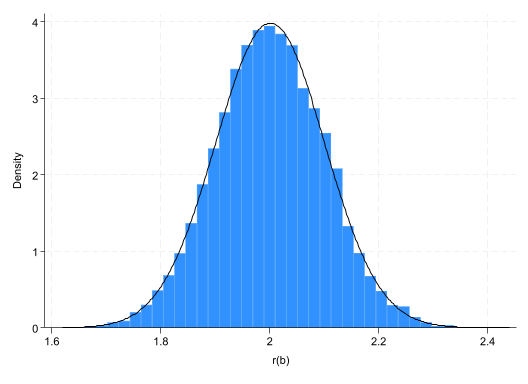

In [22]:
hist bhat,normal

当样本容量增加为1000时，$\hat\beta$的真实分布已非常接近于正态分布，可以很放心地使用大样本理论进行统计推断。